# Imports

In [45]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

# 1) Upload the photo 

In [46]:
img = cv2.imread("D:\Tempo\\red_yellow.jpg")
img = cv2.resize(img, (500,400))

# 2) Create 3 Exposures for 1 photo 

In [47]:
def LDR_exposures(img , factor):  # lighter , darker , regular 
    return np.clip(img.astype(np.float32) * factor , 0, 255).astype(np.uint8)

exposure = np.array([0.2 ,  4.0],dtype=np.float32) # 2 exposures (darker , regular , lighter)

imgs = [LDR_exposures(img , exposure[0]) , 
        img.copy() ,
        LDR_exposures(img , exposure[1])]

# 3) Merge the 3 Exposures 

In [48]:
def mergeHDR (imgs , times):
    hdr = np.zeros(imgs[0].shape , dtype=np.float32)
    weight_sum = np.zeros_like(imgs[0] , dtype=np.float32)
    
    for img , t in zip(imgs , times):
        w = 1.0 - (img.astype(np.float32) / 127.5 - 1.0) ** 2 
        hdr += w * (img.astype(np.float32) / 255.0 / t )
        weight_sum += w
    return hdr / (weight_sum +1e-8)
hdr = mergeHDR(imgs , exposure)

# 4) Tone mapping 

In [49]:
def mapping(hdr , gamma = 1.599): # gamma: how much to control the overall brightness
    lum =0.2126 * hdr[...,0] + 0.7152 * hdr[...,1] + 0.0722 * hdr[...,2]
    scale = (lum / (1 + lum)) / (lum + 1e-8)
    out = np.clip(hdr * scale[...,None] , 0 , 1) ** (1.0 / gamma)
    return (out * 255).astype(np.uint8)

result = mapping(hdr)

5) testing 

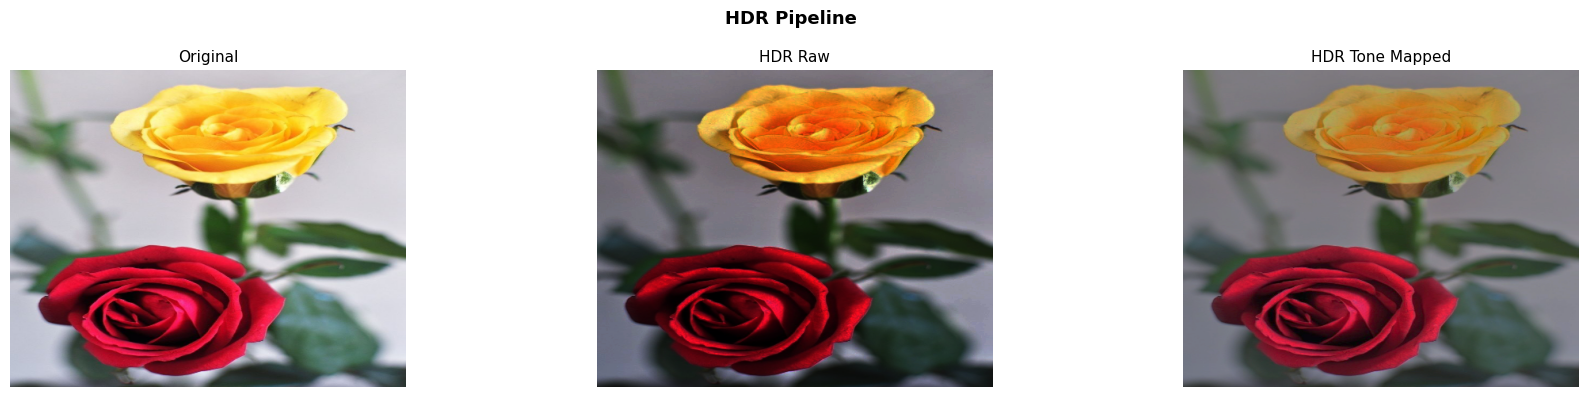

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
titles = ["Original", "HDR Raw", "HDR Tone Mapped"]
imgs   = [ imgs[1],
          (np.clip(hdr/hdr.max(), 0, 1)*255).astype(np.uint8), result]

for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle("HDR Pipeline ", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()